# Remote Work and AI/Data Science Salaries

This analysis investigates whether fully remote AI and data science jobs pay higher salaries than non-remote or hybrid roles. The question is motivated by early-career decision-making as well as broader considerations of equity and access in the data science labor market.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

The dataset is loaded from a locally stored CSV file. The raw data are not committed to the GitHub repository; instead, a download link is provided in the README to ensure reproducibility without versioning large files.

In [35]:
df = pd.read_csv("data/salaries-ai-jobs-net.csv", sep=",")

print(df.head())
print(df.shape)
print(df.info())

   work_year experience_level employment_type                   job_title  \
0       2022               MI              FT                Data Analyst   
1       2022               MI              FT                AI Scientist   
2       2022               EN              FT  Machine Learning Developer   
3       2022               MI              FT              Data Scientist   
4       2022               SE              FT               Data Engineer   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   90000             SGD          65950                 SG            50   
1  200000             USD         200000                 US           100   
2  180000             USD         180000                 US           100   
3  153000             USD         153000                 US           100   
4  210000             USD         210000                 US           100   

  company_location company_size  
0               SG            M  
1     

### Descriptive Statistics and Visualization

This section focuses on exploratory data analysis, including cleaning the dataset, computing descriptive statistics, and creating visualizations to examine how salaries vary by remote work status.

In [36]:
# Salary summary

df["salary_in_usd"].describe()

count       637.000000
mean     113275.439560
std       70874.620746
min        2859.000000
25%       63831.000000
50%      103000.000000
75%      150075.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

Salary distributions are right-skewed, as indicated by a mean that exceeds the median. Therefore, median salary is used as the primary summary statistic.

In [37]:
# Categorical value counts

print(df["remote_ratio"].value_counts())
print(df["experience_level"].value_counts())
print(df["employment_type"].value_counts())

remote_ratio
100    401
0      135
50     101
Name: count, dtype: int64
experience_level
SE    299
MI    220
EN     92
EX     26
Name: count, dtype: int64
employment_type
FT    618
PT     10
CT      5
FL      4
Name: count, dtype: int64


In [38]:
# Create remote_category variable

df["remote_category"] = df["remote_ratio"].map(
    {0: "on_site", 50: "hybrid", 100: "remote"}
)

df.sample(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,remote_category
381,2021,SE,FT,Machine Learning Engineer,70000,EUR,82744,BE,50,BE,M,hybrid
196,2022,SE,FT,Data Scientist,144000,USD,144000,US,100,US,M,remote
375,2021,EN,FT,Data Analyst,50000,USD,50000,US,100,US,M,remote
388,2021,EX,FT,Director of Data Science,250000,USD,250000,US,0,US,L,on_site
341,2021,SE,FT,Data Science Manager,240000,USD,240000,US,0,US,L,on_site


In [39]:
# Filter only to Full-time employment_type based on value counts

df = df[df["employment_type"] == "FT"]
df.shape

(618, 12)

In [40]:
# Group summaries

df.groupby("remote_category")["salary_in_usd"].describe()

,count,mean,std,min,25%,50%,75%,max
remote_category,,,,,,,,
hybrid,94.0,84049.287234,56705.923097,5707.0,54130.00,70466.5,99925.75,423000.0
on_site,134.0,108270.291045,67629.446858,2859.0,64049.25,99050.0,141075.00,450000.0
remote,390.0,123852.548718,70652.021802,4000.0,77873.00,117995.0,160000.00,600000.0


Fully remote roles have the highest median and mean salaries compared to on‑site and hybrid roles, while hybrid roles show the lowest typical compensation. The wide spread and extreme maximum values across categories indicate skewed salary distributions, reinforcing the choice to focus on medians rather than means for comparison.

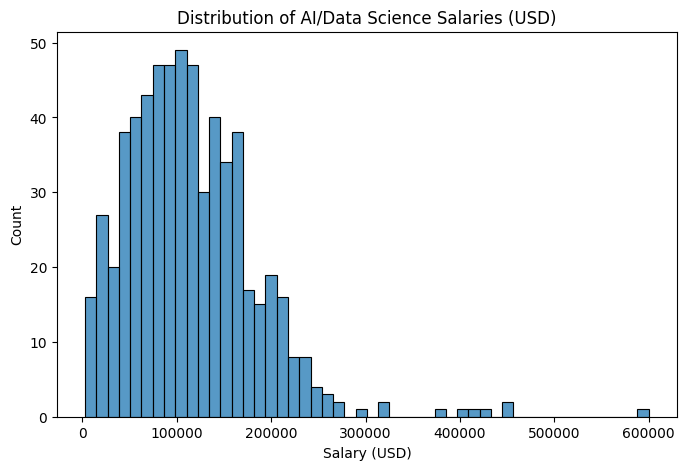

In [30]:
# Salary distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["salary_in_usd"], bins=50)
plt.title("Distribution of AI/Data Science Salaries (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Count")
plt.show()

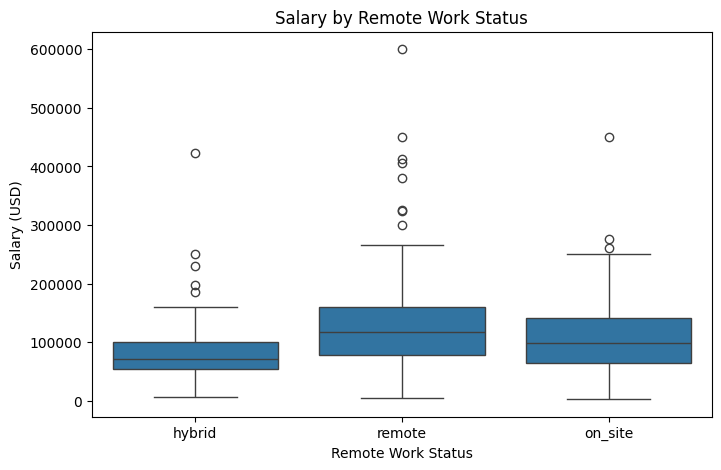

In [31]:
# Salary by remote status

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="remote_category", y="salary_in_usd")
plt.title("Salary by Remote Work Status")
plt.xlabel("Remote Work Status")
plt.ylabel("Salary (USD)")
plt.show()

The histogram shows that AI and data science salaries are strongly right‑skewed, with most salaries clustered below $150,000 and a small number of very high earners extending the upper tail. The boxplot indicates that fully remote roles tend to have higher median salaries and greater variability than on‑site and hybrid roles, while hybrid roles show the lowest typical compensation.